### Passo 1: Processamento de Dados com spaCy

#### Instalação de Ambiente:

In [ ]:
%pip install pandas spacy scikit-learn matplotlib seaborn wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
UsageError: Line magic function `%python` not found (But cell magic `%%python` exists, did you mean that instead?).


In [3]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------------------------- 0.0/12.8 MB 325.1 kB/s eta 0:00:40
     --------------------------------------- 0.1/12.8 MB 655.4 kB/s eta 0:00:20
     - -------------------------------------- 0.3/12.8 MB 2.0 MB/s eta 0:00:07
     -- ------------------------------------- 0.9/12.8 MB 4.1 MB/s eta 0:00:03
     ---- ----------------------------------- 1.3/12.8 MB 4.9 MB/s eta 0:00:03
     ----- ---------------------------------- 1.8/12.8 MB 5.6 MB/s eta 0:00:02
     ------- -------------------------------- 2.3/12.8 MB 6.2 MB/s eta 0:00:02
     --------- ------------------------------ 2.9/12.8 MB 7.2 MB/s eta 0:00:02
     ---------- ----------------------------- 3.4/12.8 MB 7.6 MB/s eta 0:00:02
     ------------ --------------------------- 4.0/12.8 MB 7.8 MB/s eta 0:00:02
     -------------- ------------------------- 4.6/12.8 MB 8.1 MB


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Importação de Libs

In [4]:
import pandas as pd
import spacy
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from wordcloud import WordCloud 

nlp = spacy.load("en_core_web_sm")

#### Criação e Consumo dos Datasets

In [5]:
# Base: https://huggingface.co/datasets/zefang-liu/phishing-email-dataset/viewer?views%5B%5D=train

# Utilização de Dataset Local (arquivo bruto)
df = pd.read_csv('dataset\phishing_emails.csv', encoding='utf-8')  

# Visualização prévia dele
df.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


#### Pré-Processamento do .CSV "Bruto"

In [6]:
def preprocess_spacy(text):
    if pd.isnull(text):
        return ""
    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and token.is_alpha]
    return " ".join(tokens)

# coluna "file" -> geral | "message" -> conversas em si
df["clean_text"] = df["Email Text"].apply(preprocess_spacy) 
df.head()

,Unnamed: 0,Email Text,Email Type,clean_text
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,disc uniformitarianism sex lang dick hudson ob...
1,1,the other side of * galicismos * * galicismo *...,Safe Email,galicismo galicismo spanish term name improper...
2,2,re : equistar deal tickets are you still avail...,Safe Email,equistar deal ticket available assist robert e...
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email,hello hot lil horny toy dream open minded pers...
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email,software incredibly low price low drapery seve...


In [7]:
# Remove a coluna "Unnamed: 0"
df.drop(columns=["Unnamed: 0"], inplace=True)

# Substitui os valores da coluna "Email Type"
df["Email Type"] = df["Email Type"].replace({
    "Safe Email": 0,
    "Phishing Email": 1
})

# Visualizar o resultado
df.head()

C:\Users\JuliodaSilvaNeves\AppData\Local\Temp\ipykernel_27228\443157546.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Email Type"] = df["Email Type"].replace({


,Email Text,Email Type,clean_text
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0,disc uniformitarianism sex lang dick hudson ob...
1,the other side of * galicismos * * galicismo *...,0,galicismo galicismo spanish term name improper...
2,re : equistar deal tickets are you still avail...,0,equistar deal ticket available assist robert e...
3,\nHello I am your hot lil horny toy.\n I am...,1,hello hot lil horny toy dream open minded pers...
4,software at incredibly low prices ( 86 % lower...,1,software incredibly low price low drapery seve...


In [8]:
# Renomear a coluna "Email Type" para "Phishing?"
df.rename(columns={"Email Type": "Phishing?"}, inplace=True)

# Remover a coluna original "Email Text"
df.drop(columns=["Email Text"], inplace=True)

# Renomear a coluna "clean_text" para "Email Text"
df.rename(columns={"clean_text": "Email Text"}, inplace=True)

# Reordenar as colunas: primeiro "Email Text", depois "Phishing?"
df = df[["Email Text", "Phishing?"]]

In [9]:
# Visualizar o resultado final
df.head(10)

,Email Text,Phishing?
0,disc uniformitarianism sex lang dick hudson ob...,0
1,galicismo galicismo spanish term name improper...,0
2,equistar deal ticket available assist robert e...,0
3,hello hot lil horny toy dream open minded pers...,1
4,software incredibly low price low drapery seve...,1
5,global risk management operation sally congrat...,0
6,sun aug wintermute mention impression read lkm...,0
7,entourage stockmogul newsletter ralph velez ge...,1
8,owe lot money dear applicant review receive ap...,1
9,coastal deal exxon participation project agree...,0


In [10]:
# Exporta o DataFrame pré-processado para um novo CSV
df.to_csv("dataset/emails_processados.csv", index=False, encoding="utf-8")

==== Classification Report ====
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       465
           1       1.00      0.78      0.87       310

    accuracy                           0.91       775
   macro avg       0.94      0.89      0.90       775
weighted avg       0.92      0.91      0.91       775

==== Confusion Matrix ====
[[465   0]
 [ 69 241]]


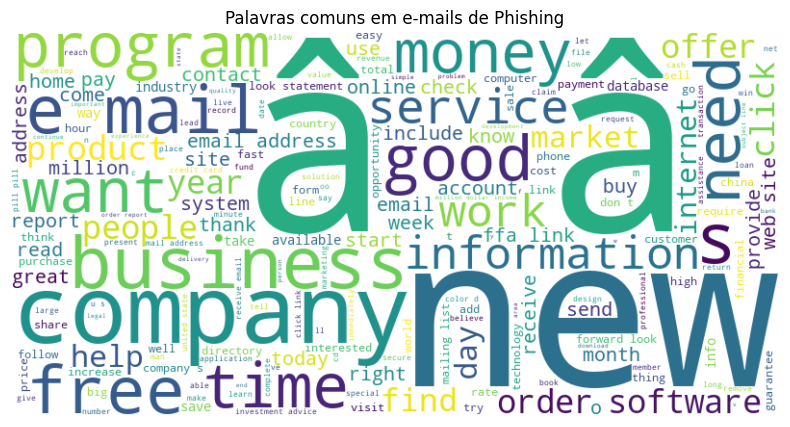

In [11]:
#### Treinamento e Avaliação do Modelo
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["Email Text"])
y = df["Phishing?"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

modelo = MultinomialNB()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("==== Classification Report ====")
print(classification_report(y_test, y_pred))
print("==== Confusion Matrix ====")
print(confusion_matrix(y_test, y_pred))

#### Nuvem de Palavras para e-mails de Phishing
texto_suspeito = " ".join(df[df["Phishing?"] == 1]["Email Text"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(texto_suspeito)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Palavras comuns em e-mails de Phishing")
plt.show()